In [10]:
!git clone https://github.com/Priya-Kumari-Chourasia/word_embed

Cloning into 'data'...
remote: Not Found
fatal: repository 'https://github.com/Priya-Kumari-Chourasia/word_embed/data/' not found


btech in vocab: True
exam in vocab: True
ug in vocab: True
phd in vocab: True
Corpus saved!
Vocabulary size: 1333
Total documents: 2479
Total tokens: 34024

Top-10 Frequent Words:
student : 599, program : 544, engineering : 522, academic : 375, course : 355, jodhpur : 330, science : 296, research : 274, department : 249, iit : 248, 
Wordcloud saved!


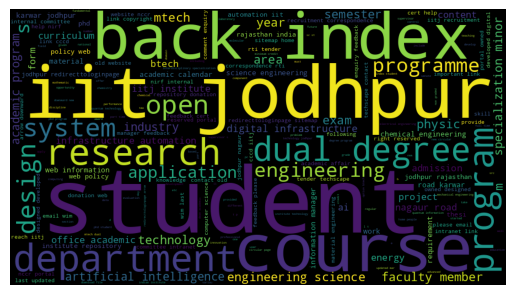

In [2]:
import os
import re
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# these are stopwords
stopwords = {
    "the","is","are","a","an","and","or","of","to","in","on","for",
    "with","by","that","this","be","will","have","has","had","at",
    "from","as","it","was","were","but","about","into","than",
    "their","there","these","those","he","she","they","them",
    "who","can","may","shall","should","could","would"
}

useless_w = {"dr","mr","mrs","ms","prof","pm"}

# doing normalization of words
def word_normal(word):

    if word.startswith("examin"):
        return "exam"

    if word.endswith("ies") and len(word) > 4:
        return word[:-3] + "y"

    if word.endswith("s") and len(word) > 3 and not word.endswith("ss"):
        return word[:-1]

    if word == "thesi":
        return "thesis"

    return word


# preprocessing the data
folder = "/content/word_embed/data"
snt = []

for file in os.listdir(folder):

    if file.endswith(".txt"):

        with open(os.path.join(folder, file), "r", encoding="utf-8") as f:

            txt = f.read().lower()

            txt = txt.replace("b.tech", "btech")
            txt = txt.replace("m.tech", "mtech")
            txt = txt.replace("ph.d", "phd")

            raw_sent = re.split(r"[.!?]", txt)

            for sent in raw_sent:

                sent = re.sub(r"[^a-z\s]", " ", sent)
                words = sent.split()

                processed = []

                for word in words:

                    if word in stopwords or word in useless_w:
                        continue

                    word = word_normal(word)

                    if not word.isalpha():
                        continue

                    processed.append(word)

                if len(processed) > 2:
                    snt.append(processed)

# building the vocabulary and removing the noise from data
all_wrds = [w for s in snt for w in s]
word_cnts = Counter(all_wrds)

min_freq = 3
strong_freq = 5

# removing the rare words from data
sentences = [
    [w for w in s if word_cnts[w] >= min_freq]
    for s in snt
]

# removing the proper nouns
sentences = [
    [w for w in s if word_cnts[w] >= strong_freq]
    for s in sentences
]

# removing all characters which are not alphabet
sentences = [
    [w for w in s if re.match("^[a-z]+$", w)]
    for s in sentences
]

# removing empty sentences
sentences = [s for s in sentences if len(s) > 2]

# this is final vocabulary
all_words = [w for s in sentences for w in s]

vocab = sorted(list(set(all_words)))
vocab_size = len(vocab)



# mapping of word to index and index to word
word_to_index = {w:i for i,w in enumerate(vocab)}
index_to_word = {i:w for i,w in enumerate(vocab)}

print("btech in vocab:", "btech" in vocab)
print("exam in vocab:", "exam" in vocab)
print("ug in vocab:", "ug" in vocab)
print("phd in vocab:", "phd" in vocab)

# saving the clean data as corpus.txt file
with open("corpus.txt", "w", encoding="utf-8") as f:
    for s in sentences:
        f.write(" ".join(s) + "\n")

print("Corpus saved!")

# showing dataset statistics
total_docs = len(sentences)
total_tokens = sum(len(s) for s in sentences)

print("Vocabulary size:", vocab_size)
print("Total documents:", total_docs)
print("Total tokens:", total_tokens)

# ---------- TOP 10 FREQUENT WORDS ----------
top10_words = word_cnts.most_common(10)

print("\nTop-10 Frequent Words:")
for word, freq in top10_words:
    print(f"{word} : {freq}", end=", " )
print()


text = " ".join(all_words)

wc = WordCloud(width=900, height=500).generate(text)

plt.imshow(wc)
plt.axis("off")
plt.savefig("wordcloud.png")

print("Wordcloud saved!")

In [3]:
import os
import re
import numpy as np
from collections import Counter

# loading the preprocessed data from corpus.txt file

sentences = []
cbow_results = []
skipgram_results = []

with open("corpus.txt", "r", encoding="utf-8") as f:
    for line in f:
        words = line.strip().split()
        if len(words) > 2:
            sentences.append(words)

print("Loaded sentences:", len(sentences))

# one hot encoding function
def ohe(idx, vocab_size):

    vec = np.zeros(vocab_size)
    vec[idx] = 1
    return vec

# generating cbow pairs
def gen_cbow_p(sentences, word_to_index, w_size):

    X = []
    y = []

    for sentence in sentences:

        sentence_len = len(sentence)

        for i, word in enumerate(sentence):

            target_id = word_to_index[word]

            start = max(0, i-w_size)
            end = min(sentence_len, i+w_size+1)

            context_ids = []

            for j in range(start, end):

                if i != j:
                    context_ids.append(word_to_index[sentence[j]])

            if len(context_ids) > 0:
                X.append(context_ids)
                y.append(target_id)

    return X, y

def init_network(vocab_size, embedding_dim):

    model = {}

    model["W1"] = np.random.randn(vocab_size, embedding_dim) * 0.01
    model["W2"] = np.random.randn(embedding_dim, vocab_size) * 0.01

    return model
# this is softmax function
def softmax(x):

    exp_x = np.exp(x - np.max(x))
    return exp_x / np.sum(exp_x)

# function for forward_cbow
def forward_cbow(model, cw):

    embeddings = []

    for idx in cw:
        #embeddings.append(model["W1"][idx])
        #x = one_hot_encode(idx, vocab_size)        # one-hot vector
        #h = x @ model["W1"]
        h = model["W1"][idx]
        embeddings.append(h)

    h = np.mean(embeddings, axis=0)

    u = h @ model["W2"]

    y_pred = softmax(u)

    return h, y_pred

# function for training the cbpow model

def train_cbow(model, X_train, y_train, epochs, lr):

    final_loss = 0

    for epoch in range(epochs):

        total_loss = 0

        for i in range(len(X_train)):

            context = X_train[i]
            target = y_train[i]

            h, y_pred = forward_cbow(model, context)

            y_true = np.zeros(vocab_size)
            y_true[target] = 1

            error = y_pred - y_true

            dW2 = np.outer(h, error)
            model["W2"] -= lr * dW2

            grad_hidden = error @ model["W2"].T

            for idx in context:
                model["W1"][idx] -= lr * grad_hidden / len(context)

            loss = -np.sum(np.log(y_pred + 1e-9) * y_true)
            total_loss += loss

        final_loss = total_loss / len(X_train)
        print("CBOW Epoch:", epoch+1, "Loss:", final_loss)

    return final_loss
window_size = [2,3,5]
embedding_dim = [50,100,300]
epochs = 10
negative_samples_list = [5, 10,15]
learning_rate = 0.01

# ---------- TRACK BEST MODELS ----------
best_cbow_model = None
best_cbow_loss = float("inf")

best_skip_model = None
best_skip_loss = float("inf")


print("\n----- CBOW EXPERIMENTS -----")

for emb in embedding_dim:
    for win in window_size:

        print(f"\nCBOW -> Embedding: {emb}, Window: {win}")

        X_cbow, y_cbow = gen_cbow_p(sentences, word_to_index, win)

        model = init_network(vocab_size, emb)

        final_loss = train_cbow(model, X_cbow, y_cbow, epochs, learning_rate)

        cbow_results.append([emb, win, round(final_loss, 4)])

        # STORE BEST MODEL
        if final_loss < best_cbow_loss:
            best_cbow_loss = final_loss
            best_cbow_model = model


# Skipgram with negative Sample

# function is generating skipgram pairs
def gen_sp(sentences, word_to_index, w_size):

    X = []
    y = []

    for sentence in sentences:

        sentence_len = len(sentence)

        for i, word in enumerate(sentence):

            target_id = word_to_index[word]

            start = max(0, i-w_size)
            end = min(sentence_len, i+w_size+1)

            for j in range(start, end):

                if i != j:

                    context_id = word_to_index[sentence[j]]

                    X.append(target_id)
                    y.append(context_id)

    return np.array(X), np.array(y)


# this function is generating negative sample
def get_neg_samples(vocab_size, pos_id, k):

    neg = []

    while len(neg) < k:

        rand = np.random.randint(0, vocab_size)

        if rand != pos_id:
            neg.append(rand)

    return neg

# function is training the skipgram model
def train_skipgram_neg(model, X_train, y_train, epochs, lr, neg_samp):
    final_loss = 0
    for epoch in range(epochs):

        total_loss = 0

        for i in range(len(X_train)):

            target = X_train[i]
            context = y_train[i]

            #target_vec = model["W1"][target]
            # one-hot encoding
            x = ohe(target, vocab_size)

            target_vec = x @ model["W1"]

            pos_score = target_vec @ model["W2"][:, context]

            sigmoid_pos = 1 / (1 + np.exp(-pos_score))


            pos_loss = -np.log(sigmoid_pos + 1e-9)
            grad_pos = sigmoid_pos - 1

            # Update W2 for positive word
            model["W2"][:, context] -= lr * grad_pos * target_vec

            # Update W1
            model["W1"][target] -= lr * grad_pos * model["W2"][:, context]

            negt = get_neg_samples(vocab_size, context, neg_samp)

            neg_loss = 0

            for neg in negt:

                neg_score = target_vec @ model["W2"][:, neg]

                sigmoid_neg = 1 / (1 + np.exp(-neg_score))

                neg_loss += -np.log(1 - sigmoid_neg + 1e-9)

                grad_neg = sigmoid_neg

                # Update W2
                model["W2"][:, neg] -= lr * grad_neg * target_vec

                # Update W1
                model["W1"][target] -= lr * grad_neg * model["W2"][:, neg]


            total_loss += pos_loss + neg_loss
        final_loss = total_loss / len(X_train)
        print("Skipgram NS Epoch:", epoch+1, final_loss)

    return final_loss

print("\n----- SKIPGRAM EXPERIMENTS -----")

for emb in embedding_dim:
    for win in window_size:
        for neg in negative_samples_list:

            print(f"\nSkipgram -> Embedding: {emb}, Window: {win}, NegSamples: {neg}")

            X_skip, y_skip = gen_sp(sentences, word_to_index, win)

            model = init_network(vocab_size, emb)

            final_loss = train_skipgram_neg(
                model, X_skip, y_skip, epochs, learning_rate, neg
            )

            skipgram_results.append([emb, win, neg, round(final_loss, 4)])

            # STORE BEST MODEL
            if final_loss < best_skip_loss:
                best_skip_loss = final_loss
                best_skip_model = model

# ---------- Printing the result table----------

print("\n===== CBOW RESULTS TABLE =====")
print("Embedding\tWindow\tFinal Loss")
for r in cbow_results:
    print(f"{r[0]}\t\t{r[1]}\t{r[2]}")


print("\n===== SKIP-GRAM RESULTS TABLE =====")
print("Embedding\tWindow\tNegSamples\tFinal Loss")
for r in skipgram_results:
    print(f"{r[0]}\t\t{r[1]}\t{r[2]}\t\t{r[3]}")

print("Models saved successfully")
embeddings = best_skip_model["W1"]
word = "engineering"   # change word

if word in word_to_index:
    vec = embeddings[word_to_index[word]]
    print(f"\n{word} -", ", ".join([str(round(v,4)) for v in vec]))


Loaded sentences: 2479

----- CBOW EXPERIMENTS -----

CBOW -> Embedding: 50, Window: 2
CBOW Epoch: 1 Loss: 7.194991445685062
CBOW Epoch: 2 Loss: 7.1940862236778935
CBOW Epoch: 3 Loss: 7.188892603046626
CBOW Epoch: 4 Loss: 7.148900031226228
CBOW Epoch: 5 Loss: 6.975331138709088
CBOW Epoch: 6 Loss: 6.736714261204846
CBOW Epoch: 7 Loss: 6.532969851276098
CBOW Epoch: 8 Loss: 6.3401772867750585
CBOW Epoch: 9 Loss: 6.137052938196432
CBOW Epoch: 10 Loss: 5.934489502467259

CBOW -> Embedding: 50, Window: 3
CBOW Epoch: 1 Loss: 7.1950492773659755
CBOW Epoch: 2 Loss: 7.194402228088754
CBOW Epoch: 3 Loss: 7.190668930951647
CBOW Epoch: 4 Loss: 7.161408427475639
CBOW Epoch: 5 Loss: 6.995894457679154
CBOW Epoch: 6 Loss: 6.7572480084392375
CBOW Epoch: 7 Loss: 6.578934462373588
CBOW Epoch: 8 Loss: 6.427466103381004
CBOW Epoch: 9 Loss: 6.270845063697373
CBOW Epoch: 10 Loss: 6.098555500495855

CBOW -> Embedding: 50, Window: 5
CBOW Epoch: 1 Loss: 7.19509765785146
CBOW Epoch: 2 Loss: 7.19467064906704
CBOW 

In [9]:
import numpy as np


embeddings = best_skip_model["W1"]

word_to_index = {word:i for i,word in enumerate(vocab)}
index_to_word = {i:word for i,word in enumerate(vocab)}

# function is calculating the cosine similarity
def cosine_sim(vec1, vec2):

    return np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2))

# finding the top 5
def gt_neig(word, top_n=5):

    if word not in word_to_index:
        print(word,"not found in vocabulary")
        return

    word_vec = embeddings[word_to_index[word]]

    similarities = []

    for i in range(len(vocab)):

        other_word = index_to_word[i]

        if other_word == word:
            continue

        other_vec = embeddings[i]

        sim = cosine_sim(word_vec, other_vec)

        similarities.append((other_word, sim))

    similarities.sort(key=lambda x:x[1], reverse=True)

    print("\nTop neighbors for:",word)

    for w,s in similarities[:top_n]:
        print(w, round(s,4))


gt_neig("research")
gt_neig("student")
gt_neig("phd")
gt_neig("exam")

# function defining the analogy
def analogy(word_a, word_b, word_c, top_n=5):

    vec = embeddings[word_to_index[word_b]] - embeddings[word_to_index[word_a]] + embeddings[word_to_index[word_c]]

    similarities = []

    for i in range(len(vocab)):

        word = index_to_word[i]

        if word in [word_a, word_b, word_c]:
            continue

        sim = cosine_sim(vec, embeddings[i])

        similarities.append((word, sim))

    similarities.sort(key=lambda x:x[1], reverse=True)

    print("\n",word_a,":",word_b,"::",word_c,": ?")

    for w,s in similarities[:top_n]:
        print(w, round(s,4))

analogy("btech","undergraduate","mtech")
analogy("student","exam","research")
analogy("bachelor","master","phd")
analogy("exam","viva","written")
analogy("student", "graduate", "researcher")
analogy("department", "faculty", "student")


Top neighbors for: research
dey 0.6414
subhasish 0.6093
titled 0.6028
facility 0.5885
fab 0.5714

Top neighbors for: student
placement 0.505
wellbeing 0.495
enrolled 0.4824
opportunity 0.4549
internship 0.4478

Top neighbors for: phd
merit 0.7131
provisionally 0.705
candidate 0.6935
selected 0.6918
shortlisted 0.68

Top neighbors for: exam
comprehensive 0.7942
voce 0.7931
viva 0.7862
duly 0.7583
final 0.7469

 btech : undergraduate :: mtech : ?
postgraduate 0.6298
january 0.5793
pgc 0.5759
pgd 0.5681
ar 0.5603

 student : exam :: research : ?
paper 0.5425
titled 0.4793
dey 0.4627
publishing 0.4618
subhasish 0.4389

 bachelor : master :: phd : ?
mmt 0.7155
merit 0.7041
ad 0.6876
joint 0.6827
doctor 0.6803

 exam : viva :: written : ?
test 0.6626
interview 0.6479
merit 0.6476
shortlisted 0.6461
ad 0.626

 student : graduate :: researcher : ?
vision 0.3418
introduction 0.3375
scientific 0.3327
active 0.3269
computing 0.3251

 department : faculty :: student : ?
placement 0.5837
internshi

Task 4 started
Vocabulary size: 1333
Vocabulary size: 1333
Word 'thesis' not in vocabulary
Word 'quiz' not in vocabulary
Words used: ['student', 'research', 'phd', 'btech', 'mtech', 'exam', 'course', 'admission', 'program', 'department', 'faculty', 'project', 'scholarship', 'class', 'paper', 'viva', 'master', 'bachelor', 'candidate', 'enrolled', 'merit', 'researcher', 'registration', 'publication']
PCA plots saved
t-SNE plots saved


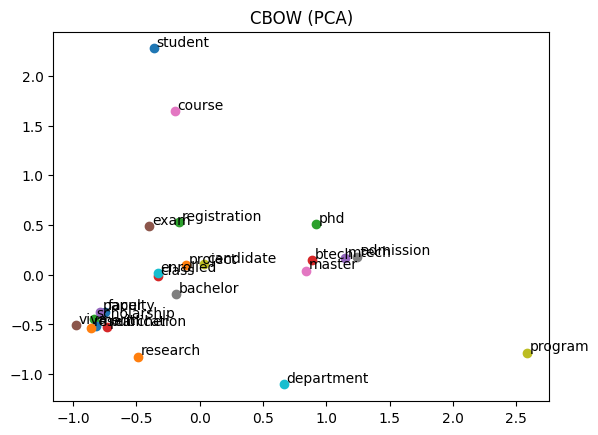

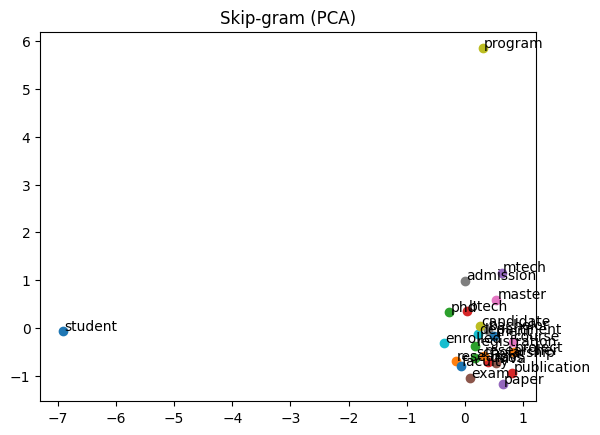

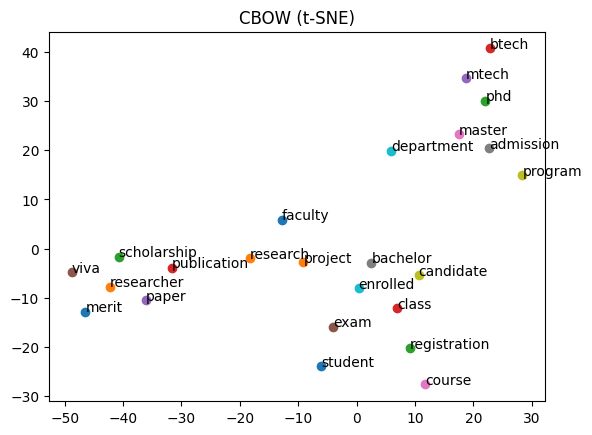

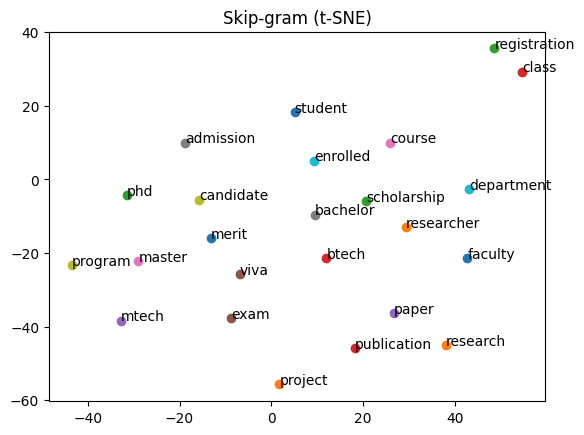

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

print("Task 4 started")


# Using models directly from memory
cbow_embeddings = best_cbow_model["W1"]
skip_embeddings = best_skip_model["W1"]

# Using same vocab from training
vocab = list(word_to_index.keys())

print("Vocabulary size:", len(vocab))
print("Vocabulary size:", len(vocab))


# select words
selected_words = [
    "student","research","phd","btech","mtech",
    "exam","course","admission","program",
    "department","faculty","project","scholarship","class","paper","viva","master","bachelor","candidate","enrolled","merit","researcher","registration","publication"
]

# Map words to indices safely
indices = []
labels = []

for w in selected_words:
    if w in vocab:
        indices.append(vocab.index(w))
        labels.append(w)
    else:
        print(f"Word '{w}' not in vocabulary")

print("Words used:", labels)


# getting the vectors
cbow_vectors = cbow_embeddings[indices]
skip_vectors = skip_embeddings[indices]


# ---------- PCA ----------
pca = PCA(n_components=2)

cbow_pca = pca.fit_transform(cbow_vectors)
skip_pca = pca.fit_transform(skip_vectors)


#  function for plot
def plot_embeddings(vectors, labels, title):
    plt.figure()
    for i, word in enumerate(labels):
        x, y = vectors[i]
        plt.scatter(x, y)
        plt.text(x + 0.02, y + 0.02, word)
    plt.title(title)


# this is PCA Plot function
plot_embeddings(cbow_pca, labels, "CBOW (PCA)")
plt.savefig("cbow_pca.png")

plot_embeddings(skip_pca, labels, "Skip-gram (PCA)")
plt.savefig("skipgram_pca.png")

print("PCA plots saved")


# ---------- t-SNE ----------
tsne = TSNE(n_components=2, random_state=42, perplexity=5)

cbow_tsne = tsne.fit_transform(cbow_vectors)
skip_tsne = tsne.fit_transform(skip_vectors)


# this is t-SNE plot
plot_embeddings(cbow_tsne, labels, "CBOW (t-SNE)")
plt.savefig("cbow_tsne.png")

plot_embeddings(skip_tsne, labels, "Skip-gram (t-SNE)")
plt.savefig("skipgram_tsne.png")

print("t-SNE plots saved")